# Exploratory Data Analysis of Global AI Job Market & Salary Trends


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---
# Data Understanding
---

In [50]:
df = pd.read_csv('ai_job_dataset1.csv')

In [51]:
df.shape

(15000, 20)

In [52]:
df.head()

,job_id,job_title,salary_usd,salary_currency,salary_local,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,Data Scientist,219728,USD,219728,EX,PT,Sweden,M,Sweden,0,"Python, Computer Vision, R, Docker",Associate,13,Transportation,2024-09-23,2024-10-31,1132,6.6,TechCorp Inc
1,AI00002,Head of AI,230237,JPY,25326070,EX,PT,Japan,L,Japan,50,"Kubernetes, MLOps, Tableau, Python",Bachelor,10,Transportation,2024-07-26,2024-09-12,2299,8.5,Cloud AI Solutions
2,AI00003,Data Engineer,128890,EUR,109557,EX,CT,Germany,S,Germany,100,"Spark, Scala, Hadoop, PyTorch, GCP",Bachelor,12,Automotive,2025-01-19,2025-03-28,1329,5.5,Quantum Computing Inc
3,AI00004,Computer Vision Engineer,96349,USD,96349,MI,FL,Finland,L,Finland,50,"MLOps, Linux, Tableau, Python",PhD,2,Automotive,2024-07-20,2024-09-06,1132,6.8,Cognitive Computing
4,AI00005,Robotics Engineer,63065,EUR,53605,EN,FT,France,S,France,100,"R, Scala, SQL, GCP, Python",Associate,0,Finance,2025-03-16,2025-05-09,2011,9.3,Advanced Robotics


In [53]:
df.dtypes

job_id                        str
job_title                     str
salary_usd                  int64
salary_currency               str
salary_local                int64
experience_level              str
employment_type               str
company_location              str
company_size                  str
employee_residence            str
remote_ratio                int64
required_skills               str
education_required            str
years_experience            int64
industry                      str
posting_date                  str
application_deadline          str
job_description_length      int64
benefits_score            float64
company_name                  str
dtype: object

---
# Data Cleaning
---

In [54]:
df.isnull().sum()  # To check if Null Exists.

job_id                    0
job_title                 0
salary_usd                0
salary_currency           0
salary_local              0
experience_level          0
employment_type           0
company_location          0
company_size              0
employee_residence        0
remote_ratio              0
required_skills           0
education_required        0
years_experience          0
industry                  0
posting_date              0
application_deadline      0
job_description_length    0
benefits_score            0
company_name              0
dtype: int64

In [55]:
df.drop_duplicates(inplace=True)

---
# Feature Engineering
---

In [56]:
df['posting_date'] = pd.to_datetime(df['posting_date'])  # Converting str into Date Columns
df['application_deadline'] = pd.to_datetime(df['application_deadline'])

In [57]:
df.dtypes

job_id                               str
job_title                            str
salary_usd                         int64
salary_currency                      str
salary_local                       int64
experience_level                     str
employment_type                      str
company_location                     str
company_size                         str
employee_residence                   str
remote_ratio                       int64
required_skills                      str
education_required                   str
years_experience                   int64
industry                             str
posting_date              datetime64[us]
application_deadline      datetime64[us]
job_description_length             int64
benefits_score                   float64
company_name                         str
dtype: object

In [58]:
df['posting_Month'] = df['posting_date'].dt.month_name()
df['posting_Year'] = df['posting_date'].dt.year
df['Deadline Month'] = df['application_deadline'].dt.month_name()

## Business Question 1

### Which month has the highest number of AI job postings?

In [59]:
df['posting_Month'].value_counts()

posting_Month
March        1953
January      1846
April        1846
February     1711
October      1006
August        977
December      977
July          975
November      958
September     921
May           918
June          912
Name: count, dtype: int64

### Observation

- March recorded the highest number of AI job postings (1,953).
- June had the lowest number of job postings (912).
- Hiring activity appears to peak during the first quarter of the year.

## Business Question 2

### Which month has the highest number of application deadlines?

In [60]:
df['Deadline Month'].value_counts() 

Deadline Month
March        1873
May          1863
April        1813
June         1277
February     1272
January      1038
December     1024
July         1005
October       984
November      962
September     950
August        939
Name: count, dtype: int64

### Observation

- March had the highest number of application deadlines (1,873).
- Most deadlines are concentrated between March and May.

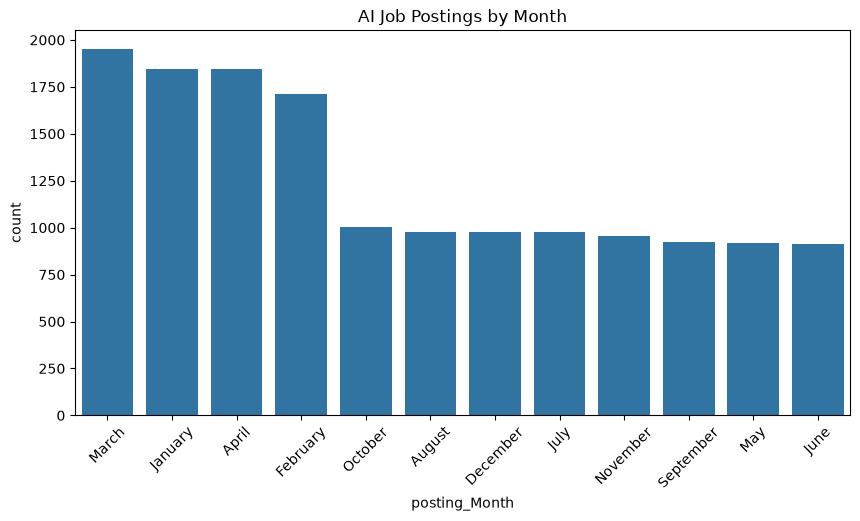

In [61]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="posting_Month",
    order=df["posting_Month"].value_counts().index
)

plt.title("AI Job Postings by Month")
plt.xticks(rotation=45)
plt.show()

## Summary Statistics of Numerical Features

In [62]:
df.describe()

,salary_usd,salary_local,remote_ratio,years_experience,posting_date,application_deadline,job_description_length,benefits_score,posting_Year
count,15000.000000,1.500000e+04,15000.000000,15000.000000,15000,15000,15000.000000,15000.000000,15000.000000
mean,121991.938267,8.292366e+05,50.196667,6.365667,2024-08-30 19:08:09.600000,2024-10-13 06:02:58.560000,1500.852600,7.499540,2024.242133
min,16621.000000,1.662100e+04,0.000000,0.000000,2024-01-01 00:00:00,2024-01-16 00:00:00,500.000000,5.000000,2024.000000
25%,74978.500000,7.383075e+04,0.000000,2.000000,2024-05-01 00:00:00,2024-06-15 00:00:00,998.750000,6.300000,2024.000000
50%,107261.500000,1.090355e+05,50.000000,5.000000,2024-08-31 00:00:00,2024-10-15 00:00:00,1512.000000,7.500000,2024.000000
75%,155752.250000,1.673278e+05,100.000000,10.000000,2024-12-28 00:00:00,2025-02-09 00:00:00,1994.000000,8.800000,2024.000000
max,410273.000000,3.368541e+07,100.000000,19.000000,2025-04-30 00:00:00,2025-07-11 00:00:00,2499.000000,10.000000,2025.000000
std,63968.361846,3.425325e+06,40.844084,5.598551,NaN,NaN,574.724647,1.444202,0.428389


### Observation

- The dataset contains 15,000 job postings with no missing numerical records.
- The average AI salary is approximately **$122,000**, with salaries ranging from **$16,621** to **$410,273**.
- 25% of jobs pay less than about **$75k**.
- Half the jobs pay below **$107k**.
- The median required experience is **5 years**.
- Job descriptions contain an average of **1,501 words**.
- The average benefits score is **7.5/10**.

## Summary Statistics of Categorical Features

In [63]:
df.describe(include='object')

C:\Users\Om Soni\AppData\Local\Temp\ipykernel_14124\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,job_id,job_title,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,required_skills,education_required,industry,company_name,posting_Month,Deadline Month
count,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000
unique,15000,20,8,4,4,20,3,50,13651,4,15,16,12,12
top,AI00001,Machine Learning Engineer,USD,EX,CT,Switzerland,L,Switzerland,"Python, TensorFlow, Tableau",Bachelor,Government,Machine Intelligence Group,March,March
freq,1,824,7453,3843,3841,819,5087,669,9,3863,1035,986,1953,1873


### Observation

- The dataset contains **20 unique job titles**.
- There are **4 experience levels** and **4 employment types**.
- Jobs are spread across **20 company locations**.
- Employees belong to **50 different countries**.
- The `required_skills` column contains **13,651 unique skill combinations**, indicating a wide variety of technical requirements.

## Business Question 3

### How are AI job salaries distributed?

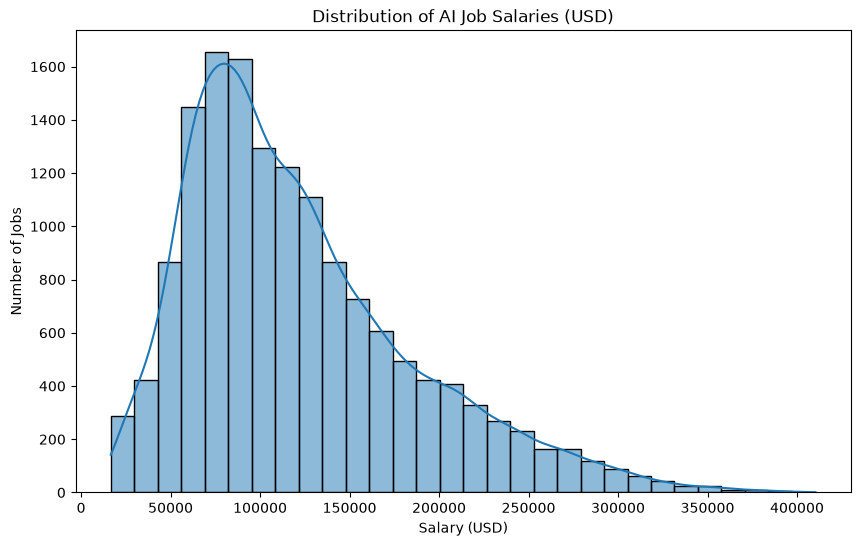

In [64]:
plt.figure(figsize=(10,6))

sns.histplot(
    data = df,
    x = "salary_usd",
    bins = 30,
    kde = True
)

plt.title("Distribution of AI Job Salaries (USD)")
plt.xlabel("Salary (USD)")
plt.ylabel("Number of Jobs")

plt.show()

### Observation

- Most AI job salaries are concentrated between **$70,000 and $160,000**.
- The distribution is slightly right-skewed, indicating that a smaller number of jobs offer exceptionally high salaries.
- A few high-paying roles above **$300,000** can be considered potential outliers.

## Business Question 4

### How does experience level affect AI job salaries?

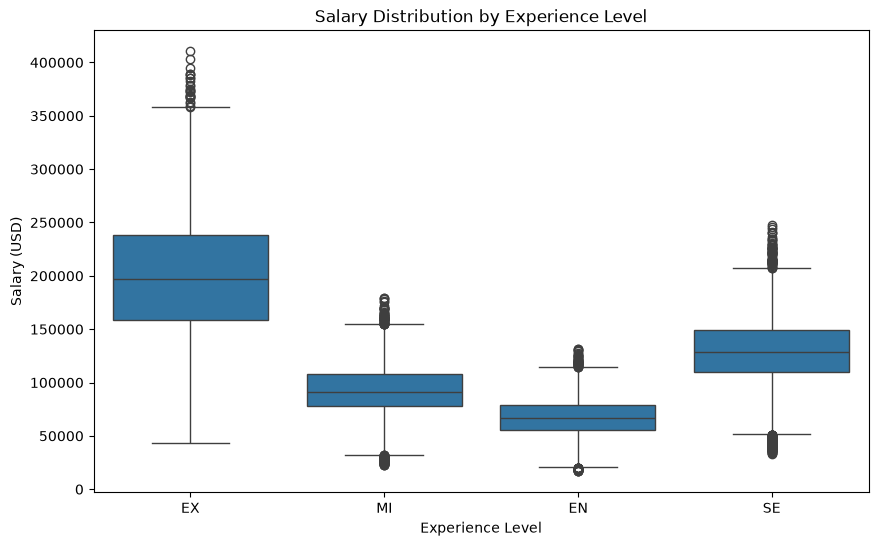

In [65]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x = "experience_level",
    y = "salary_usd"
)

plt.title("Salary Distribution by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Salary (USD)")

plt.show()

### Observation

- Salaries generally increase with higher experience levels.
- Executive-level professionals have the highest median salary.
- Entry-level roles have the lowest salary range.
- Senior and Executive positions show greater salary variation, indicating a wider range of compensation.

## Business Question 5

### Which Top 10 AI job titles are most in demand?

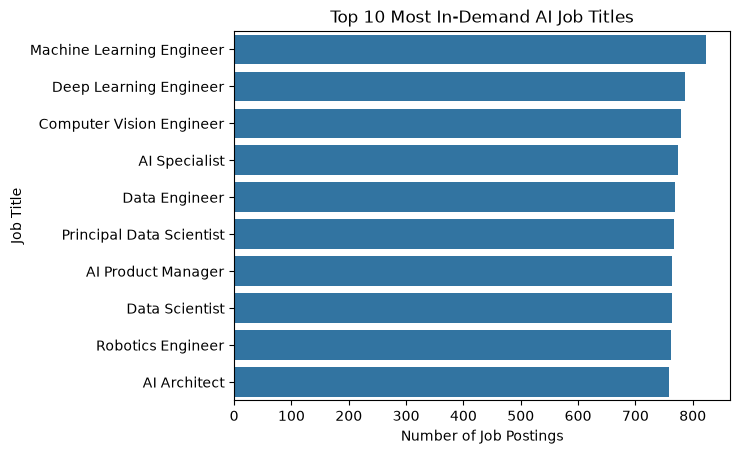

In [66]:
top_demand = df['job_title'].value_counts().head(10)

plt.Figure(figsize=(10,6))
sns.barplot(
    x=top_demand.values,
    y=top_demand.index
)

plt.title("Top 10 Most In-Demand AI Job Titles")
plt.xlabel("Number of Job Postings")
plt.ylabel("Job Title")

plt.show()

## Business Question 6

### Does company size influence AI salaries?

This analysis examines whether employees at small, medium, or large companies receive different salary levels.

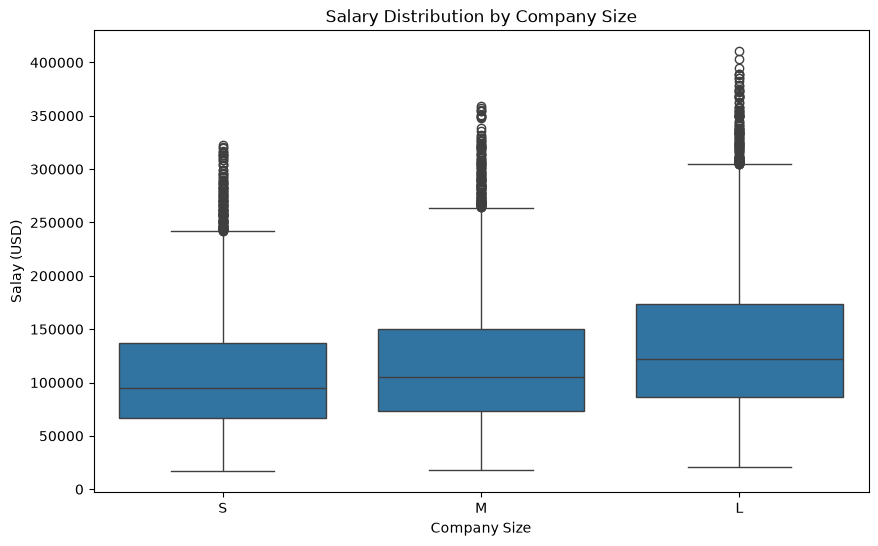

In [67]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x = 'company_size',
    y = 'salary_usd',
    order=['S','M','L']
)

plt.title("Salary Distribution by Company Size")
plt.xlabel("Company Size")
plt.ylabel("Salay (USD)")

plt.show()

### Observation

- Large companies (L) have the highest median salary among all company sizes.
- Medium-sized companies (M) offer slightly higher median salaries than small companies (S).
- Salary variability increases with company size, as large companies show a wider interquartile range (IQR).
- Large companies also have the highest number of high-paying outliers, with some salaries exceeding **$400,000**.
- Small companies generally offer lower salaries with a comparatively narrower salary distribution.

In [68]:
df.groupby('company_size')['salary_usd'].agg(
    ['count', 'mean', 'median', 'min', 'max'])

,count,mean,median,min,max
company_size,,,,,
L,5087,138466.265186,121967.0,21072,410273
M,4938,118876.322803,105421.0,18052,359202
S,4975,108239.176080,94953.0,16621,322650


## Business Question 7

### Which industries offer the highest average AI salaries?

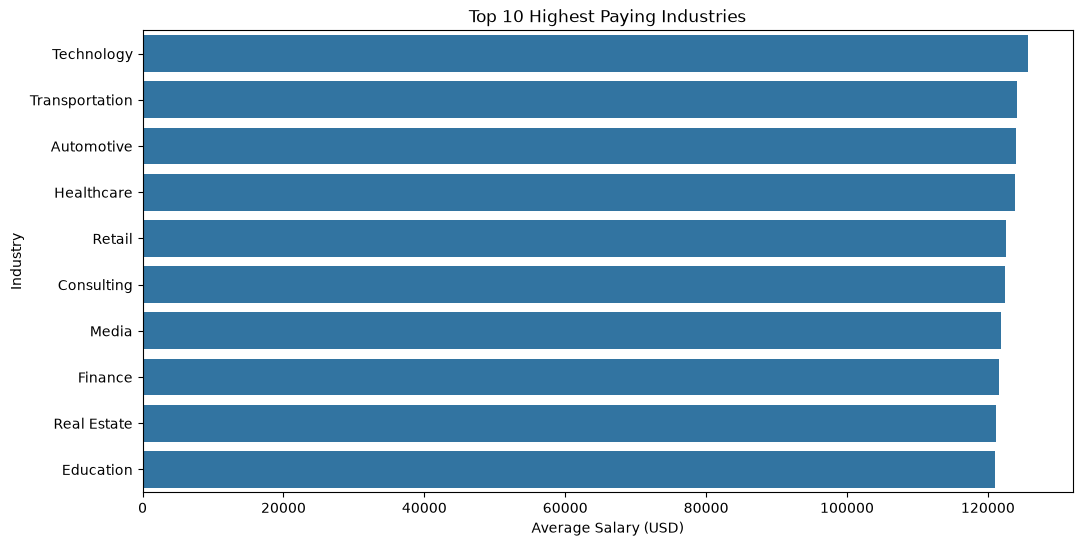

In [69]:
top_industries = (
    df.groupby("industry")["salary_usd"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_industries.values,
    y=top_industries.index
)

plt.title("Top 10 Highest Paying Industries")
plt.xlabel("Average Salary (USD)")
plt.ylabel("Industry")

plt.show()

In [70]:
df.groupby("industry")["salary_usd"].agg(
    ["count","mean","median"]
).sort_values("mean", ascending=False).head(10)

,count,mean,median
industry,,,
Technology,1011,125733.192878,110437.0
Transportation,951,124138.421661,111013.0
Automotive,1015,123930.440394,112677.0
Healthcare,984,123916.978659,109435.5
Retail,978,122527.614519,105195.5
Consulting,1021,122383.428991,110559.0
Media,972,121880.372428,108319.5
Finance,1018,121582.105108,103880.0
Real Estate,1005,121122.930348,105890.0


### Observation

- Technology has the highest average AI salary among all industries in the dataset.
- Transportation and Automotive industries closely follow Technology in terms of average salary.
- Education records the lowest average salary among the top **10** industries.
- The average salaries across the top **10** industries are relatively close, indicating that compensation is fairly consistent across different AI industries in this dataset.
- Overall, the salary difference between the highest and lowest-paying industries is modest, suggesting that industry has a limited impact on average AI salaries compared to other factors such as experience level or company size.

## Business Question 8

### Does years of experience influence AI salaries?

This analysis examines the relationship between years of professional experience and annual salary in the AI job market.

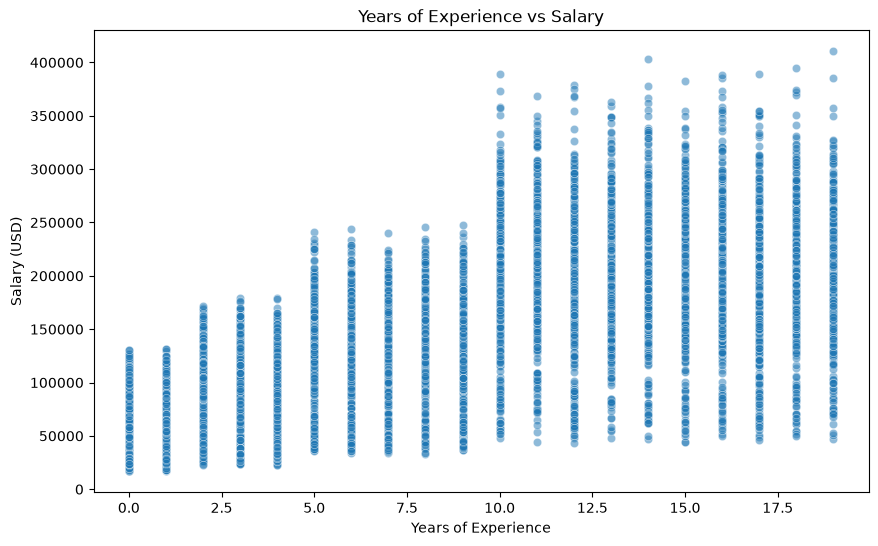

In [71]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="years_experience",
    y="salary_usd",
    alpha=0.5
)

plt.title("Years of Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary (USD)")

plt.show()

### Observation

- There is a clear positive relationship between years of experience and salary in the AI job market.
- Professionals with 0–4 years of experience generally receive lower salaries, while salaries tend to increase as experience grows.
- Employees with 10 or more years of experience have access to significantly higher salary ranges, with some salaries exceeding $400,000.
- The spread of salaries becomes wider as years of experience increase, indicating greater variability in compensation for experienced professionals.

## Business Question 9

### What are the most common employment types in the AI job market?

This analysis explores the distribution of employment types to understand the hiring preferences of organizations.

In [72]:
# Convert Labels

employment_map = {
    "FT" : "Full-Time",
    "PT" : "Part-Time",
    "CT" : "Contract",
    "FL" : "Freelance"
}

df['employment_name'] = df['employment_type'].map(employment_map)

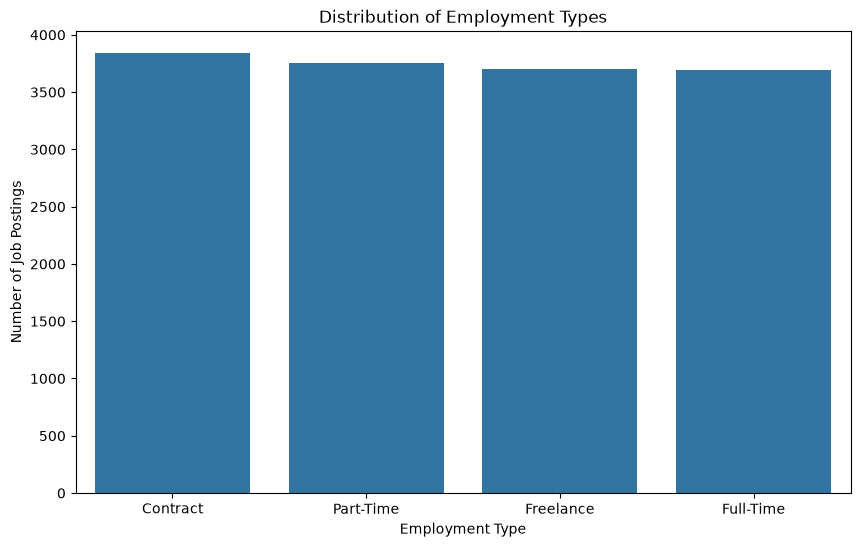

In [73]:
# Visualization

plt.figure(figsize=(10,6))

sns.countplot(
    data = df,
    x = 'employment_name',
    order = df['employment_name'].value_counts().index
)

plt.title("Distribution of Employment Types")
plt.xlabel("Employment Type")
plt.ylabel("Number of Job Postings")

plt.show()

In [74]:
df['employment_name'].value_counts()

employment_name
Contract     3841
Part-Time    3757
Freelance    3705
Full-Time    3697
Name: count, dtype: int64

### Observation

- Contract positions have the highest **3841** of job postings in the dataset.
- Part-Time, Freelance, and Full-Time roles have very similar numbers of job postings.
- The distribution of employment types is fairly balanced, with only minor differences between categories.
- No single employment type overwhelmingly dominates the AI job market in this dataset, indicating a well-distributed representation of different employment arrangements.

## Business Question 10

### Which numerical variables are most strongly correlated?

This analysis examines relationships between numerical variables to identify patterns that may influence salary and other job characteristics.

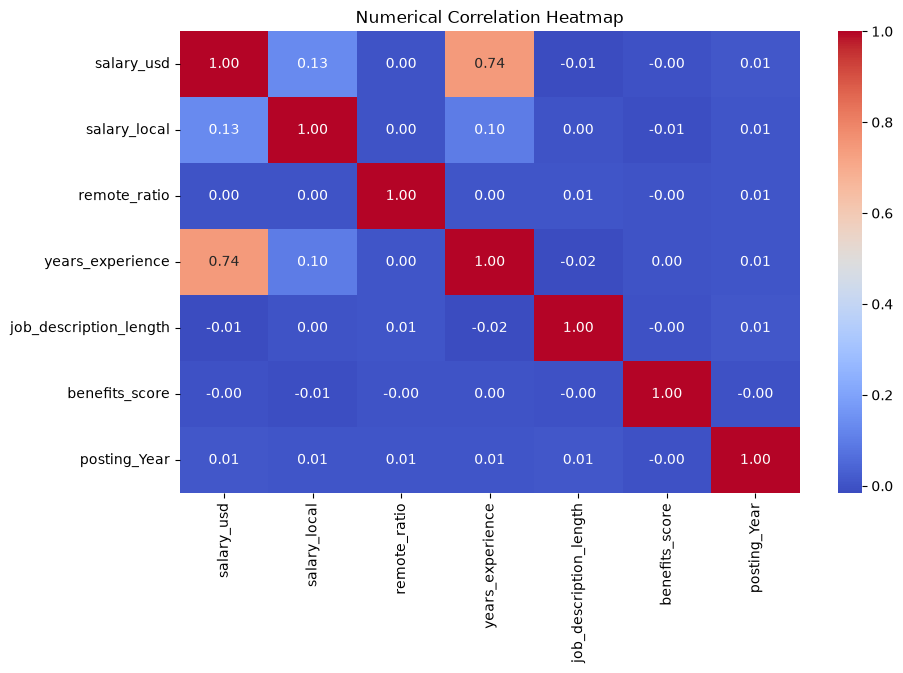

In [75]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include = "number").corr(),
    annot = True,
    cmap = "coolwarm",
    fmt = ".2f"
)

plt.title("Numerical Correlation Heatmap")

plt.show()

### Observation

- Salary (USD) has a strong positive correlation **(0.74)** with years of experience, indicating that more experienced professionals generally earn higher salaries.
- Salary (USD) has only a weak positive correlation **(0.13)** with salary in local currency, reflecting differences in currency values across countries.
- Remote ratio, benefits score, job description length, and posting year show little to no correlation with salary.
- Overall, years of experience is the most influential numerical factor associated with salary in this dataset.